<a href="https://colab.research.google.com/github/ederson-data/-Olympic-Games-Data-Analytics-ETL-Project/blob/main/bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, r2_score, classification_report

In [18]:
# Load Data
bank = pd.read_csv('bank.csv', sep=";")
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [19]:
# Optional quick checks
print("Shape:", bank.shape)
print("\nMissing values:\n", bank.isna().sum())
print("\nDuplicate rows:", bank.duplicated().sum())
print("\nTarget values before cleaning:", bank["y"].unique())

# Drop duplicate rows if any
bank = bank.drop_duplicates().copy()

# =========================
# 2. CLEAN TARGET y ONCE
# =========================
bank["y"] = bank["y"].astype(str).str.lower().str.strip()
bank["y"] = bank["y"].map({"yes": 1, "no": 0})

# Drop rows where target became invalid/missing
bank = bank.dropna(subset=["y"]).copy()
bank["y"] = bank["y"].astype(int)

print("\nTarget values after cleaning:", bank["y"].unique())
print("Target nulls:", bank["y"].isna().sum())

# =========================
# 3. CLEAN FEATURES
# =========================
# Separate feature columns
X_raw = bank.drop(columns=["y"]).copy()

# Numeric and categorical columns
num_cols = X_raw.select_dtypes(include=["number"]).columns
cat_cols = X_raw.select_dtypes(include=["object"]).columns

# Fill numeric missing values with median
X_raw[num_cols] = X_raw[num_cols].fillna(X_raw[num_cols].median())

# Fill categorical missing values with 'unknown'
X_raw[cat_cols] = X_raw[cat_cols].fillna("unknown")

# Standardize text columns
for col in cat_cols:
    X_raw[col] = X_raw[col].astype(str).str.lower().str.strip()

# =========================
# 4. FEATURE ENGINEERING
# =========================
# Create age groups from RAW age values, before scaling
if "age" in X_raw.columns:
    X_raw["age_group"] = pd.cut(
        X_raw["age"],
        bins=[0, 30, 45, 60, 100],
        labels=["Young", "Early_Adulthood", "Middle_Age", "Senior"],
        include_lowest=True
    )

# =========================
# 5. ENCODE CATEGORICALS
# =========================
X = pd.get_dummies(X_raw, drop_first=True)
y = bank["y"]

# Final null check
print("\nAny nulls left in X?", X.isna().sum().sum())
print("Any nulls left in y?", y.isna().sum())

# If something is still wrong, show bad columns
if X.isna().sum().sum() > 0:
    print("\nColumns with remaining nulls:")
    print(X.isna().sum()[X.isna().sum() > 0])

# =========================
# 6. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 7. SCALE ONLY FOR LOGISTIC REGRESSION
# =========================
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[X_train.columns] = scaler.fit_transform(X_train)
X_test_scaled[X_test.columns] = scaler.transform(X_test)

# =========================
# 8. BUILD MODELS
# =========================
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# =========================
# 9. EVALUATE
# =========================
models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test)
}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)

    # probability scores for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None

    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    if auc is not None:
        print("ROC-AUC:", round(auc, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Shape: (4521, 17)

Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate rows: 0

Target values before cleaning: ['no' 'yes']

Target values after cleaning: [0 1]
Target nulls: 0

Any nulls left in X? 0
Any nulls left in y? 0

===== Logistic Regression =====
Accuracy: 0.8961
ROC-AUC: 0.8904

Confusion Matrix:
[[778  23]
 [ 71  33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       801
           1       0.59      0.32      0.41       104

    accuracy                           0.90       905
   macro avg       0.75      0.64      0.68       905
weighted avg       0.88      0.90      0.88       905


===== Decision Tree =====
Accuracy: 0.8917
ROC-AUC: 0.8174

Confusion Ma

job
blue-collar      0.927061
entrepreneur     0.910714
services         0.908873
unemployed       0.898438
technician       0.891927
self-employed    0.890710
admin.           0.878661
housemaid        0.875000
management       0.864809
unknown          0.815789
student          0.773810
retired          0.765217
Name: 0, dtype: float64
y
0    1403.211750
1    1571.955854
Name: balance, dtype: float64


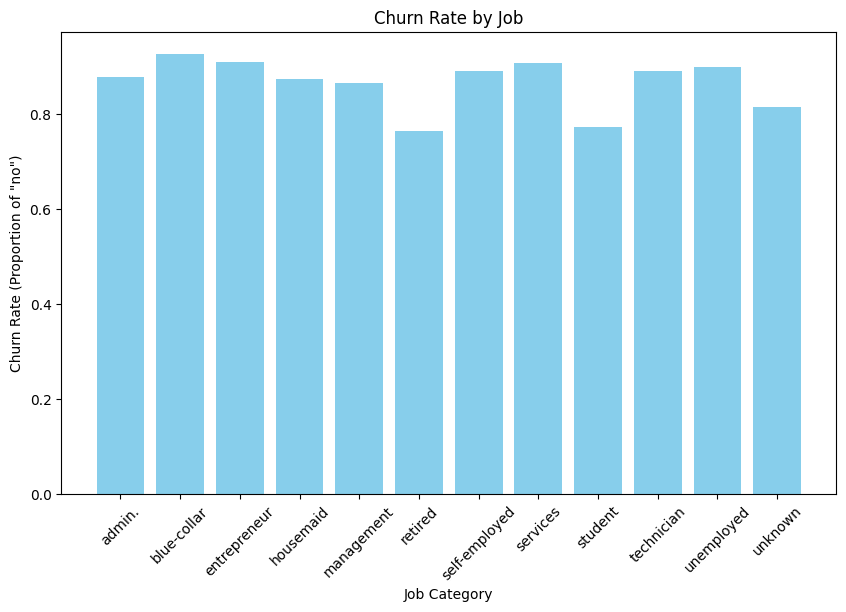

In [22]:
# Calculate churn rate by job
job_churn = bank.groupby('job')['y'].value_counts(normalize=True).unstack()
print(job_churn[0].sort_values(ascending=False))

# Check relationship between balance and churn
print(bank.groupby('y')['balance'].mean())

plt.figure(figsize=(10, 6))
plt.bar(x=job_churn.index, height=job_churn[0], color='skyblue')

plt.title('Churn Rate by Job')
plt.xlabel('Job Category')
plt.ylabel('Churn Rate (Proportion of "no")')
plt.xticks(rotation=45)
plt.show()

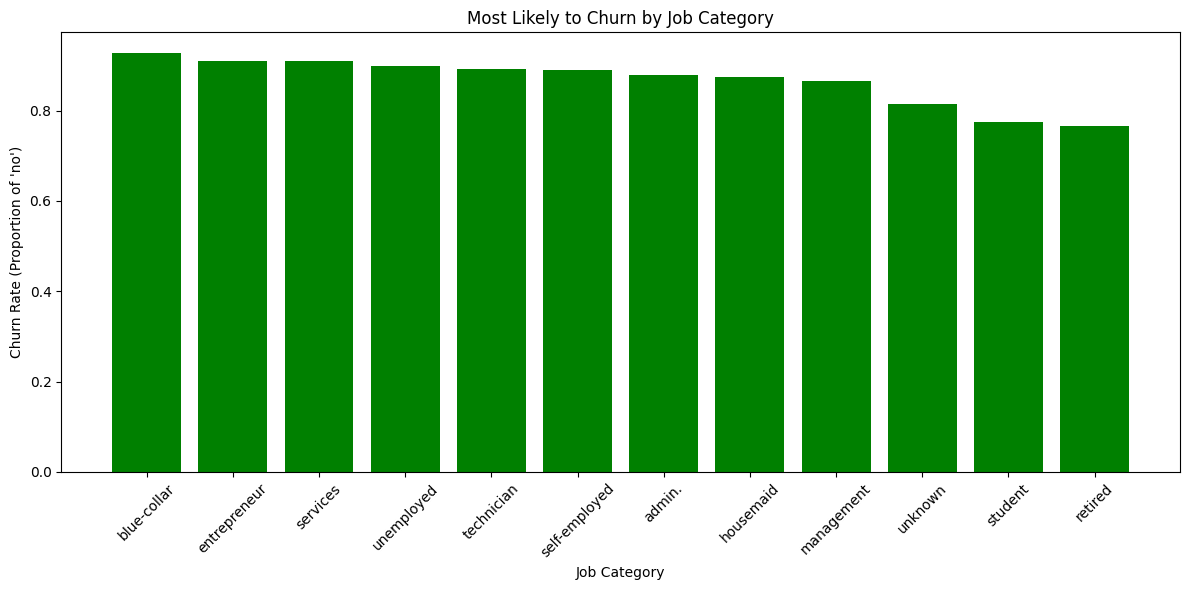

In [24]:
# 1. Calculation (ensure your dataframe is named 'bank')
churn_by_job = bank.groupby('job')['y'].value_counts(normalize=True).unstack()
# Sort the data first so the chart is easier to read
churn_sorted = churn_by_job[0].sort_values(ascending=False)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.bar(x=churn_sorted.index, height=churn_sorted.values, color="green")

plt.title("Most Likely to Churn by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Churn Rate (Proportion of 'no')")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

y
0    1403.211750
1    1571.955854
Name: balance, dtype: float64


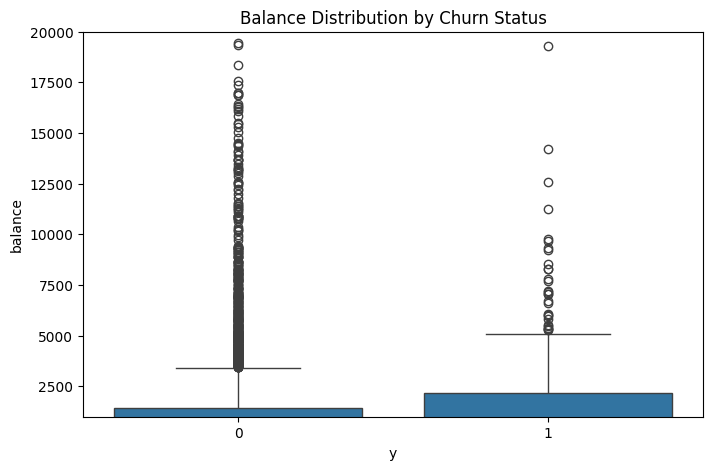

In [29]:
# Compare average balance for those who said 'no' vs 'yes'
print(bank.groupby('y')['balance'].mean())

plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='balance', data=bank)
plt.ylim(1000, 20000)
plt.title('Balance Distribution by Churn Status')
plt.show()

education
primary      0.905605
unknown      0.898396
secondary    0.893755
tertiary     0.857037
Name: 0, dtype: float64


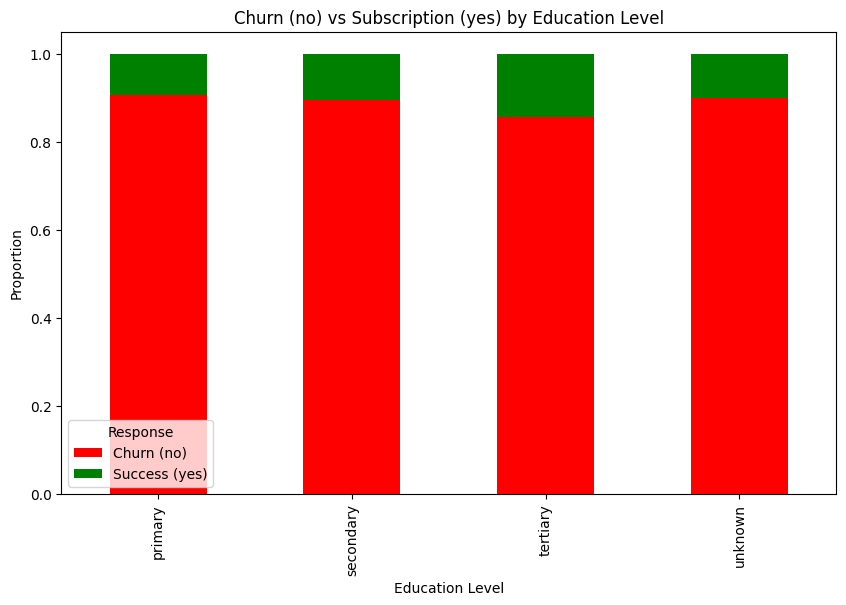

In [31]:
# Calculate churn (no) vs success (yes) percentages
edu_churn = bank.groupby('education')['y'].value_counts(normalize=True).unstack()

# Sort by churn rate ('no') to see who declines most
print(edu_churn[0].sort_values(ascending=False))

edu_churn.plot(kind='bar', stacked=True, color=['red', 'green'], figsize=(10,6))
plt.title('Churn (no) vs Subscription (yes) by Education Level')
plt.ylabel('Proportion')
plt.xlabel('Education Level')
plt.legend(title='Response', labels=['Churn (no)', 'Success (yes)'])
plt.show()

y                0         1
marital                     
divorced  0.854167  0.145833
married   0.900965  0.099035
single    0.860368  0.139632
y                 0         1
age_group                    
Young      0.857595  0.142405
Middle     0.898192  0.101808
Senior     0.622047  0.377953


/tmp/ipykernel_322/3882282297.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(bank.groupby('age_group')['y'].value_counts(normalize=True).unstack())


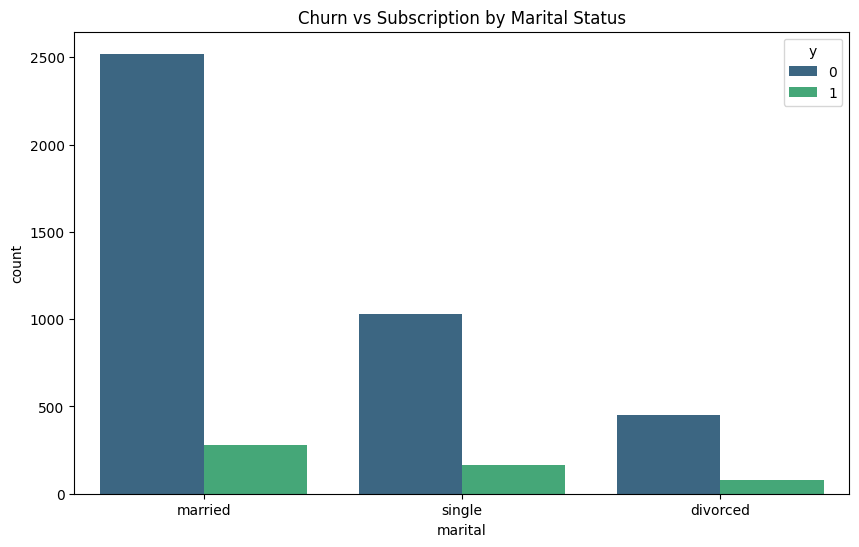

In [32]:
# Check churn by marital status
print(bank.groupby('marital')['y'].value_counts(normalize=True).unstack())

# Check churn by age bins
bank['age_group'] = pd.cut(bank['age'], bins=[0, 30, 60, 100], labels=['Young', 'Middle', 'Senior'])
print(bank.groupby('age_group')['y'].value_counts(normalize=True).unstack())

plt.figure(figsize=(10,6))
sns.countplot(x='marital', hue='y', data=bank, palette='viridis')
plt.title('Churn vs Subscription by Marital Status')
plt.show()